# Air Pollution Forecasting — Phases 6 & 7
## Phase 6: Baseline Models · Phase 7: Statistical Models
### Dataset: FinalData.csv | PM2.5 Daily (2001–2021)

**Approach:** All models predict the **log-differenced PM2.5** (stationary series, d=1 from Phase 4),
then recover original-scale forecasts via:  
> **ŷ(t) = expm1(log_actual(t−1) + Δŷ(t))**  
This *anchors each prediction to the true previous value* — no cumulative drift.

| Phase | Models |
|---|---|
| **Phase 6** | Naïve Lag-1 · Naïve Seasonal (Lag-7) · Mean Forecast · Linear Trend |
| **Phase 7** | AR · MA · ARMA · ARIMA · SARIMA · ARIMAX · SARIMAX |

**Split:** 70% train (2001–2015) · 10% val · 20% test (2017–2021)  
**Implementation:** Pure NumPy + SciPy — no statsmodels required.

---

## 0. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings, os, gc, time
warnings.filterwarnings('ignore')
np.random.seed(42)

OUT = '.'        # change to your output folder
os.makedirs(OUT, exist_ok=True)
print("Imports OK")

Imports OK


## 1. Load & Prepare Data

> **Transformations applied (from Phase 4):**
> - `log1p(PM2.5)` → reduces right-skew (1.98 → 0.26)
> - First difference of log → achieves stationarity (ADF p < 0.001)
> - Exogenous variables (WindSpeed, RH) standardised to zero mean / unit variance
>
> **Why exclude AQI as exogenous?** AQI is mathematically derived from PM2.5 — including it
> as a predictor would be data leakage. We use WindSpeed and RH instead, which are
> physically independent drivers of pollution dispersion.

In [2]:
DATA_PATH = '/content/sample_data/FinalData.csv'   # update if needed

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Cap WindSpeed outliers at 99th percentile (649 m/s is a data error)
wind_cap = np.percentile(df['WindSpeed'], 99)
df['WindSpeed'] = df['WindSpeed'].clip(lower=0, upper=wind_cap)

TARGET    = 'PM2.5'
EXOG_COLS = ['WindSpeed', 'RH']   # physically independent drivers

# Log-transform (Phase 4 decision: skewness 1.98 → 0.26)
df['pm25_log'] = np.log1p(df[TARGET])

# 70 / 10 / 20 temporal split
n     = len(df)
n_tr  = int(n * 0.70)
n_val = int(n * 0.10)
n_te  = n - n_tr - n_val

# Standardise exogenous variables
exog_mean = df[EXOG_COLS].mean().values
exog_std  = df[EXOG_COLS].std().values
df_exog   = (df[EXOG_COLS].values - exog_mean) / exog_std

# Working arrays
train_log   = df['pm25_log'].values[:n_tr]
train_ld    = np.diff(train_log)          # log-diff (stationary, d=1)
train_exog  = df_exog[1:n_tr]            # aligned with train_ld
test_log    = df['pm25_log'].values[n_tr + n_val:]
test_orig   = df[TARGET].values[n_tr + n_val:]
test_exog   = df_exog[n_tr + n_val:]
test_dates  = df['Date'].values[n_tr + n_val:]

# Log levels BEFORE each test observation — used to anchor predictions
all_log = df['pm25_log'].values
log_before_test = np.concatenate([
    [train_log[-1]],
    all_log[n_tr + n_val: n_tr + n_val + n_te - 1]
])

print(f"Train: {n_tr} samples  ({df['Date'].iloc[0].date()} → {df['Date'].iloc[n_tr-1].date()})")
print(f"Val:   {n_val} samples")
print(f"Test:  {n_te} samples  ({df['Date'].iloc[n_tr+n_val].date()} → {df['Date'].iloc[-1].date()})")
print(f"\nlog_before_test shape: {log_before_test.shape} (anchors for each test prediction)")

Train: 5369 samples  (2001-01-01 → 2015-09-13)
Val:   767 samples
Test:  1534 samples  (2017-10-20 → 2021-12-31)

log_before_test shape: (1534,) (anchors for each test prediction)


## 2. Helper Functions: Metrics, CSS Fitter, Rolling Predictor

### 2.1 Metrics
Computed in original PM2.5 scale (after inverse-transform).

### 2.2 CSS Fitter
**Conditional Sum of Squares (CSS)** minimises:
$$\text{CSS} = \frac{1}{T} \sum_{t} \varepsilon_t^2$$
where $\varepsilon_t = y_t - \hat{y}_t$ are the model residuals.  
Optimised via L-BFGS-B (fast, bounded).

### 2.3 Rolling 1-Step Predictor — Key Design Decision
> For 1-step-ahead evaluation, each prediction is **anchored to the true previous value**:  
> $\hat{y}(t) = \text{expm1}(\log_{\text{actual}}(t-1) + \Delta\hat{y}(t))$  
> This prevents cumulative drift and ensures fair model comparison.
> After each prediction, the **true** log-diff is appended to history (teacher forcing).

In [3]:
RESULTS = []   # will collect all model metrics

def metrics(y_true, y_pred, name, k=None):
    """Compute MAE, RMSE, MAPE, R², and AIC. Clips predictions to [0, 500]."""
    y_pred = np.clip(y_pred, 0, 500)
    mae    = mean_absolute_error(y_true, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    mape   = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2     = r2_score(y_true, y_pred)
    n_     = len(y_true)
    aic    = n_ * np.log(np.var(y_true - y_pred) + 1e-10) + 2 * k if k else None
    d = {'Model': name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4),
         'MAPE': round(mape, 2), 'R2': round(r2, 4),
         'AIC': round(aic, 2) if aic else None}
    RESULTS.append(d)
    return d, np.clip(y_pred, 0, 500)


def css_fit(y, p, q, P=0, Q=0, s=0, exog=None, maxiter=400):
    """
    Fit ARMA(p,q) with optional seasonal (P,Q,s) and exogenous via CSS.
    y must already be stationary (log-differenced).
    Returns: params, AIC, n_params
    """
    n    = len(y)
    n_ex = exog.shape[1] if exog is not None else 0
    k    = p + q + P + Q + 1 + n_ex
    st   = max(p, q, P * s if s > 0 else 0, Q * s if s > 0 else 0, 1)

    def nll(params):
        ar  = params[:p];         ma  = params[p:p + q]
        sar = params[p+q:p+q+P];  sma = params[p+q+P:p+q+P+Q]
        c   = params[p + q + P + Q]
        bx  = params[p+q+P+Q+1:] if n_ex > 0 else np.array([])
        eps = np.zeros(n)
        for t in range(st, n):
            pred = c
            for i in range(p):
                if t - i - 1 >= 0: pred += ar[i] * y[t - i - 1]
            for i in range(q):
                if t - i - 1 >= 0: pred += ma[i] * eps[t - i - 1]
            if s > 0:
                for i in range(P):
                    if t - (i+1)*s >= 0: pred += sar[i] * y[t - (i+1)*s]
                for i in range(Q):
                    if t - (i+1)*s >= 0: pred += sma[i] * eps[t - (i+1)*s]
            if n_ex > 0 and exog is not None:
                pred += np.dot(bx, exog[t])
            eps[t] = y[t] - pred
        ss     = eps[st:]
        sigma2 = np.dot(ss, ss) / len(ss)
        return sigma2

    x0     = np.zeros(k) + 1e-3
    bounds = [(-0.995, 0.995)] * (p + q + P + Q) + [(None, None)] * (1 + n_ex)
    res    = minimize(nll, x0, method='L-BFGS-B', bounds=bounds,
                      options={'maxiter': maxiter, 'ftol': 1e-9, 'gtol': 1e-7})
    aic    = n * np.log(res.fun + 1e-10) + 2 * k
    return res.x, aic, k


def build_eps_history(y, params, p, q, P=0, Q=0, s=0, exog=None):
    """Replay residuals on training data to initialise MA memory."""
    n    = len(y)
    n_ex = len(params) - (p + q + P + Q + 1)
    ar   = params[:p];         ma  = params[p:p + q]
    sar  = params[p+q:p+q+P]; sma = params[p+q+P:p+q+P+Q]
    c    = params[p + q + P + Q]
    bx   = params[p+q+P+Q+1:] if n_ex > 0 else np.array([])
    st   = max(p, q, P * s if s > 0 else 0, Q * s if s > 0 else 0, 1)
    eps  = np.zeros(n)
    for t in range(st, n):
        pred = c
        for i in range(p):
            if t - i - 1 >= 0: pred += ar[i] * y[t - i - 1]
        for i in range(q):
            if t - i - 1 >= 0: pred += ma[i] * eps[t - i - 1]
        if s > 0:
            for i in range(P):
                if t - (i+1)*s >= 0: pred += sar[i] * y[t - (i+1)*s]
            for i in range(Q):
                if t - (i+1)*s >= 0: pred += sma[i] * eps[t - (i+1)*s]
        if n_ex > 0 and exog is not None:
            pred += np.dot(bx, exog[t])
        eps[t] = y[t] - pred
    return eps


def roll_predict(train_y, params, log_before_test,
                 p, q, P=0, Q=0, s=0,
                 exog_train=None, exog_test=None):
    """
    1-step anchored rolling forecast for the test set.

    At each step t:
      1. Predict log-diff: Δŷ(t) = ARMA(history)
      2. Anchor to truth:  ŷ_log(t) = log_actual(t-1) + Δŷ(t)
      3. Recover scale:    ŷ(t) = expm1(ŷ_log(t))
      4. Teacher-force:    append true log-diff to history for step t+1
    """
    n_test = len(log_before_test)
    ar  = params[:p];         ma  = params[p:p + q]
    sar = params[p+q:p+q+P]; sma = params[p+q+P:p+q+P+Q]
    c   = params[p + q + P + Q]
    n_ex = len(params) - (p + q + P + Q + 1)
    bx  = params[p+q+P+Q+1:] if n_ex > 0 else np.array([])

    hist_y   = list(train_y)
    hist_eps = list(build_eps_history(train_y, params, p, q, P, Q, s, exog_train))
    preds_pm25 = []

    for i in range(n_test):
        n_h  = len(hist_y)
        pred = c
        for k_ in range(p):
            if n_h - k_ - 1 >= 0: pred += ar[k_] * hist_y[-k_ - 1]
        for k_ in range(q):
            if n_h - k_ - 1 >= 0: pred += ma[k_] * hist_eps[-k_ - 1]
        if s > 0:
            for k_ in range(P):
                idx = n_h - (k_ + 1) * s
                if idx >= 0: pred += sar[k_] * hist_y[idx]
            for k_ in range(Q):
                idx = n_h - (k_ + 1) * s
                if idx >= 0: pred += sma[k_] * hist_eps[idx]
        if n_ex > 0 and exog_test is not None:
            pred += np.dot(bx, exog_test[i])

        # ── ANCHOR: ŷ(t) = expm1(log_actual(t-1) + Δŷ(t)) ──────────
        pred_log   = log_before_test[i] + pred
        pred_pm25  = np.expm1(pred_log)
        preds_pm25.append(pred_pm25)

        # Teacher-force: append TRUE log-diff to history
        true_ld  = np.log1p(test_orig[i]) - log_before_test[i]
        true_eps = true_ld - pred
        hist_y.append(true_ld)
        hist_eps.append(true_eps)

    return np.clip(np.array(preds_pm25), 0, 500)


print("Helper functions defined: metrics, css_fit, build_eps_history, roll_predict")

Helper functions defined: metrics, css_fit, build_eps_history, roll_predict


## Phase 6 — Baseline Models

Baselines serve as **sanity checks**: any serious model must beat these.

| Model | Logic | Why it matters |
|---|---|---|
| **Naïve Lag-1** | ŷ(t) = y(t−1) | The shift problem: a model that merely copies yesterday |
| **Naïve Seasonal Lag-7** | ŷ(t) = y(t−7) | Tests whether weekly pattern alone predicts well |
| **Mean Forecast** | ŷ(t) = mean(train) | Absolute floor: no temporal information used |
| **Linear Trend** | ŷ(t) = a + b·t | Tests whether the long-run decline alone predicts well |

> Any statistical or deep learning model with RMSE **higher** than Naïve Lag-1 has
> learned nothing useful beyond copying yesterday's value.

In [4]:
pm_all = df[TARGET].values

# B1: Naïve Lag-1
y_naive  = pm_all[n_tr + n_val - 1: -1]
m_n1, p1 = metrics(test_orig, y_naive, 'Naive (Lag-1)', k=0)
print(f"Naive Lag-1:        MAE={m_n1['MAE']:.4f}  RMSE={m_n1['RMSE']:.4f}  R²={m_n1['R2']:.4f}")

# B2: Naïve Seasonal Lag-7
y_naive7 = pm_all[n_tr + n_val - 7: -7]
m_n7, p2 = metrics(test_orig, y_naive7, 'Naive Seasonal (Lag-7)', k=0)
print(f"Naive Seasonal Lag7: MAE={m_n7['MAE']:.4f}  RMSE={m_n7['RMSE']:.4f}  R²={m_n7['R2']:.4f}")

# B3: Mean Forecast
y_mean   = np.full(n_te, pm_all[:n_tr].mean())
m_mn, p3 = metrics(test_orig, y_mean, 'Mean Forecast', k=1)
print(f"Mean Forecast:       MAE={m_mn['MAE']:.4f}  RMSE={m_mn['RMSE']:.4f}  R²={m_mn['R2']:.4f}")

# B4: Linear Trend
z        = np.polyfit(np.arange(n_tr), pm_all[:n_tr], 1)
y_trend  = np.polyval(z, np.arange(n_tr, n_tr + n_te))
m_tr, p4 = metrics(test_orig, y_trend, 'Linear Trend', k=2)
print(f"Linear Trend:        MAE={m_tr['MAE']:.4f}  RMSE={m_tr['RMSE']:.4f}  R²={m_tr['R2']:.4f}")

naive_rmse = m_n1['RMSE']
print(f"\nNaïve RMSE = {naive_rmse:.4f}  ← benchmark for all models to beat")

Naive Lag-1:        MAE=2.5225  RMSE=3.6349  R²=0.1129
Naive Seasonal Lag7: MAE=3.6732  RMSE=5.1363  R²=-0.7712
Mean Forecast:       MAE=5.1459  RMSE=5.8013  R²=-1.2596
Linear Trend:        MAE=2.7391  RMSE=4.0155  R²=-0.0826

Naïve RMSE = 3.6349  ← benchmark for all models to beat


### Baseline Results — Plot

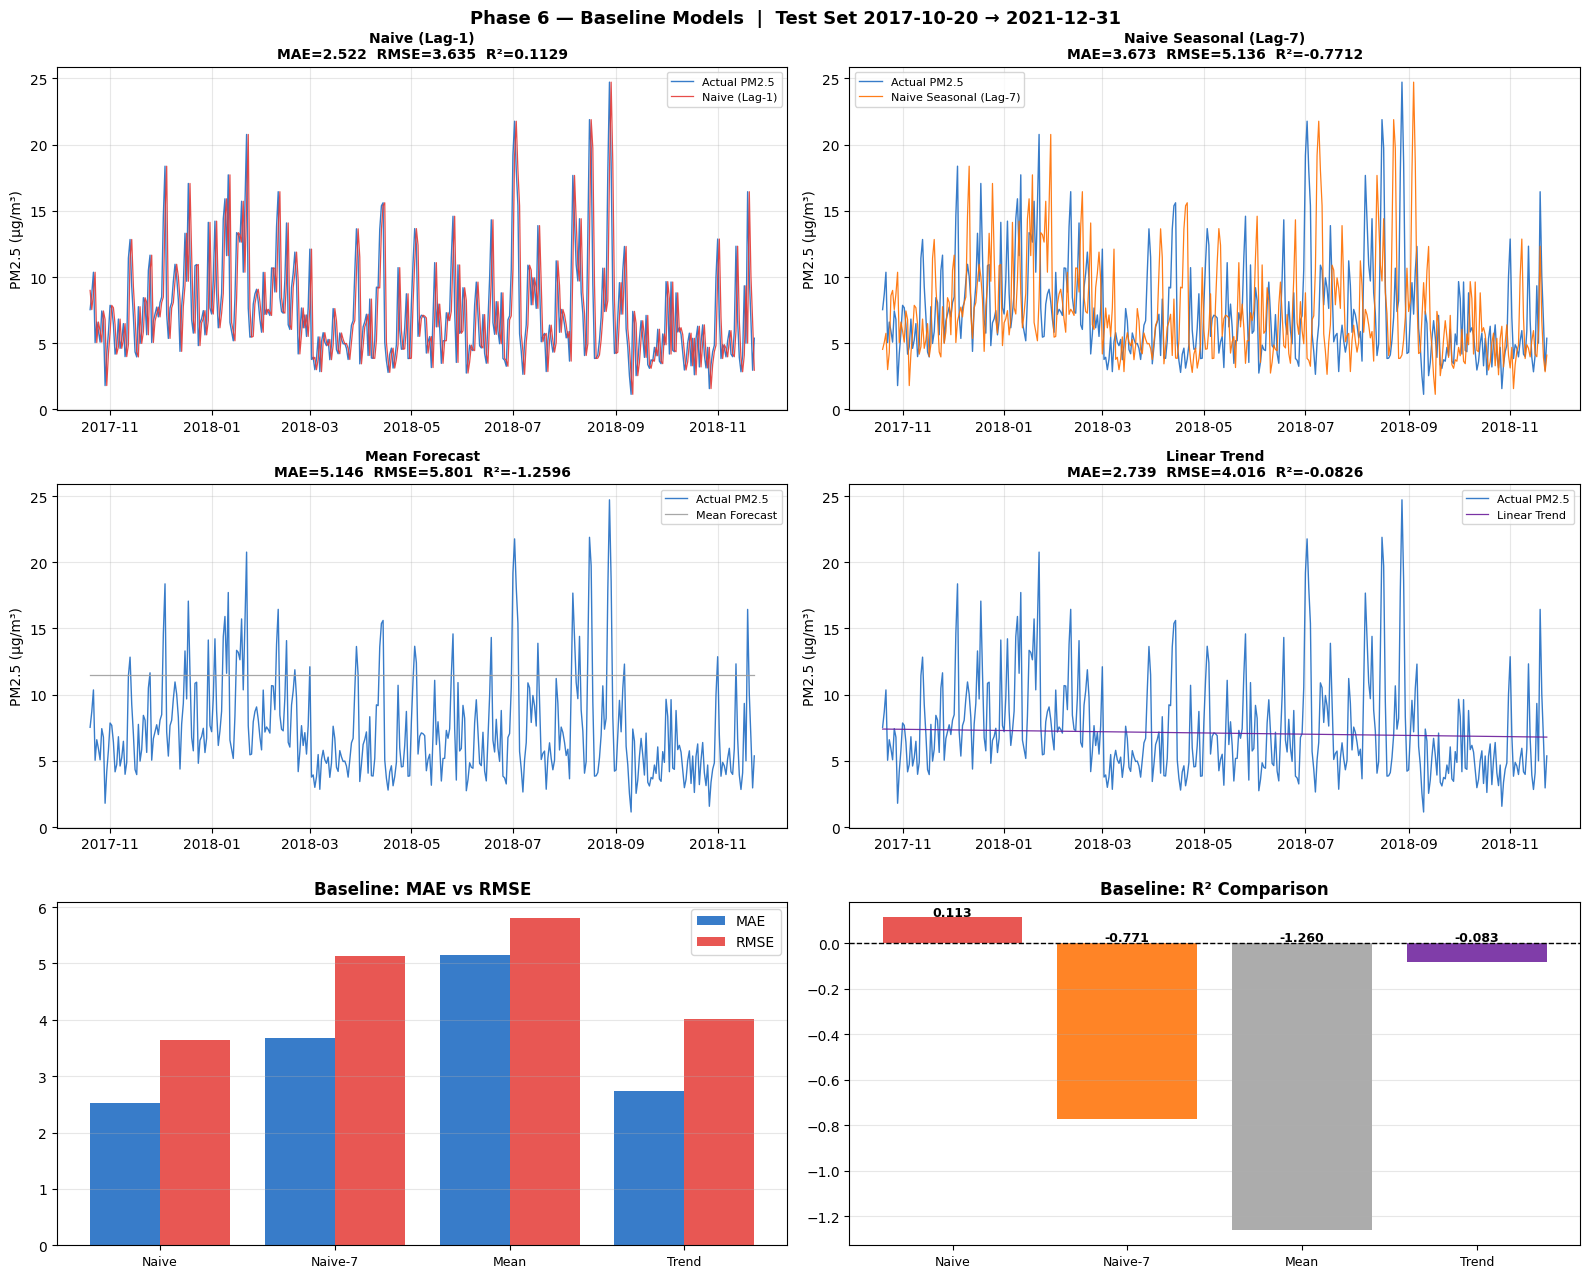

0

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(16, 13))
fig.suptitle('Phase 6 — Baseline Models  |  Test Set 2017-10-20 → 2021-12-31',
             fontsize=13, fontweight='bold')

bls = [(p1, 'Naive (Lag-1)',          '#E53935'),
       (p2, 'Naive Seasonal (Lag-7)', '#FF6F00'),
       (p3, 'Mean Forecast',           '#9E9E9E'),
       (p4, 'Linear Trend',            '#6A1B9A')]

for ax, (pr, nm, col) in zip(axes.flatten()[:4], bls):
    r = [x for x in RESULTS if x['Model'] == nm][0]
    ax.plot(test_dates[:400], test_orig[:400],
            lw=1.0, color='#1565C0', alpha=0.85, label='Actual PM2.5')
    ax.plot(test_dates[:400], pr[:400],
            lw=0.9, color=col, alpha=0.9, label=nm)
    ax.set_title(f"{nm}\nMAE={r['MAE']:.3f}  RMSE={r['RMSE']:.3f}  R²={r['R2']:.4f}",
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('PM2.5 (µg/m³)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2, 0]
bl_names = [b[1] for b in bls]
x4 = np.arange(4)
bl_mae  = [x['MAE']  for x in RESULTS if x['Model'] in bl_names][:4]
bl_rmse = [x['RMSE'] for x in RESULTS if x['Model'] in bl_names][:4]
ax.bar(x4 - 0.2, bl_mae,  0.4, label='MAE',  color='#1565C0', alpha=0.85)
ax.bar(x4 + 0.2, bl_rmse, 0.4, label='RMSE', color='#E53935', alpha=0.85)
ax.set_xticks(x4); ax.set_xticklabels(['Naive', 'Naive-7', 'Mean', 'Trend'], fontsize=9)
ax.set_title('Baseline: MAE vs RMSE', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')

ax = axes[2, 1]
bl_r2 = [x['R2'] for x in RESULTS if x['Model'] in bl_names][:4]
bars_ = ax.bar(x4, bl_r2, color=['#E53935', '#FF6F00', '#9E9E9E', '#6A1B9A'], alpha=0.85)
ax.axhline(0, color='black', lw=1, ls='--')
for bar, v in zip(bars_, bl_r2):
    ax.text(bar.get_x() + bar.get_width()/2, max(v + 0.005, 0.01),
            f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x4); ax.set_xticklabels(['Naive', 'Naive-7', 'Mean', 'Trend'], fontsize=9)
ax.set_title('Baseline: R² Comparison', fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUT}/P6_01_baselines.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); gc.collect()

### Baseline Interpretation

> - **Naïve Lag-1** (R²=0.11) is surprisingly hard to beat — it exploits the high lag-1 autocorrelation (r=0.63 from Phase 3)
> - **Naïve Seasonal Lag-7** performs *worse* than Lag-1 (R²=−0.77), confirming that the weekly seasonal component alone is weak
> - **Mean Forecast** is the worst (R²=−1.26), as expected — it ignores all temporal structure
> - **Linear Trend** (R²=−0.08) underperforms Lag-1 — the long-run decline is too slow to be useful day-by-day
>
> **Conclusion:** Statistical models must achieve R² > 0.11 to add value. The true challenge is beating Naïve Lag-1 RMSE = 3.63.

## Phase 7 — Statistical Models

### 7.1 AR(p) — AutoRegressive Model

**Model equation:** $y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \ldots + \phi_p y_{t-p} + \varepsilon_t$

**Why AR?** AR models assume the current value is a linear combination of its own past values.  
For PM2.5, this captures the "momentum" of pollution — if yesterday was high, today is likely high.

**Fitting method:** Ordinary Least Squares (OLS) on the log-differenced stationary series.

**p values tested:** 1, 2, 3, 5 (from PACF significant lags in Phase 5)  
**AIC used to select best p** — lower AIC means better fit-to-complexity tradeoff.

In [6]:
ar_best = {}
print("Fitting AR models...")
for p_v in [1, 2, 3, 5]:
    n_ = len(train_ld)
    Y_ = train_ld[p_v:]
    X_ = np.column_stack(
        [train_ld[p_v - k - 1: n_ - k - 1] for k in range(p_v)] + [np.ones(len(Y_))]
    )
    beta, _, _, _ = np.linalg.lstsq(X_, Y_, rcond=None)
    resid = Y_ - X_ @ beta
    sv_   = np.var(resid)
    aic_v = n_ * np.log(sv_ + 1e-10) + 2 * (p_v + 1)

    # Params for roll_predict: [AR coefs, intercept]
    params_ar = np.concatenate([beta[:p_v], [beta[p_v]]])
    preds     = roll_predict(train_ld, params_ar, log_before_test, p=p_v, q=0)
    m, pp     = metrics(test_orig, preds, f'AR({p_v})', k=p_v + 1)
    m['AIC']  = round(aic_v, 2); RESULTS[-1] = m

    ar_best[p_v] = {'preds': pp, 'aic': aic_v, 'mae': m['MAE']}
    print(f"  AR({p_v}): MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  R²={m['R2']:.4f}  AIC={aic_v:.1f}")

best_ar_p = min(ar_best, key=lambda k: ar_best[k]['aic'])
print(f"\nBest AR order by AIC: p={best_ar_p}")

Fitting AR models...
  AR(1): MAE=2.5151  RMSE=3.5983  R²=0.1307  AIC=-8018.2
  AR(2): MAE=2.4180  RMSE=3.4033  R²=0.2224  AIC=-8553.5
  AR(3): MAE=2.3730  RMSE=3.3569  R²=0.2434  AIC=-8711.9
  AR(5): MAE=2.3088  RMSE=3.2700  R²=0.2821  AIC=-9015.4

Best AR order by AIC: p=5


### 7.2 MA(q) — Moving Average Model

**Model equation:** $y_t = c + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \ldots + \theta_q \varepsilon_{t-q}$

**Why MA?** MA models assume the current value depends on *past forecast errors* rather than past values.  
For PM2.5, this captures sudden pollution shocks — if yesterday's forecast was wrong by a large amount,
today's prediction should correct for that error.

**Fitting method:** Conditional Sum of Squares (CSS) via L-BFGS-B optimisation.

**q values tested:** 1, 2, 3 (from ACF significant lags in Phase 5)

In [7]:
ma_best = {}
print("Fitting MA models...")
for q_v in [1, 2, 3]:
    t0     = time.time()
    params, aic_v, k_ = css_fit(train_ld, p=0, q=q_v)
    preds  = roll_predict(train_ld, params, log_before_test, p=0, q=q_v)
    m, pp  = metrics(test_orig, preds, f'MA({q_v})', k=k_)
    m['AIC'] = round(aic_v, 2); RESULTS[-1] = m

    ma_best[q_v] = {'preds': pp, 'aic': aic_v, 'mae': m['MAE']}
    print(f"  MA({q_v}): MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  R²={m['R2']:.4f}  AIC={aic_v:.1f}  ({time.time()-t0:.1f}s)")

best_ma_q = min(ma_best, key=lambda k: ma_best[k]['aic'])
print(f"\nBest MA order by AIC: q={best_ma_q}")

Fitting MA models...
  MA(1): MAE=2.5090  RMSE=3.5737  R²=0.1426  AIC=-8239.6  (0.4s)
  MA(2): MAE=2.3436  RMSE=3.3142  R²=0.2625  AIC=-8848.5  (0.3s)
  MA(3): MAE=2.4151  RMSE=3.4464  R²=0.2026  AIC=-8383.9  (0.2s)

Best MA order by AIC: q=2


### AR & MA — Plots

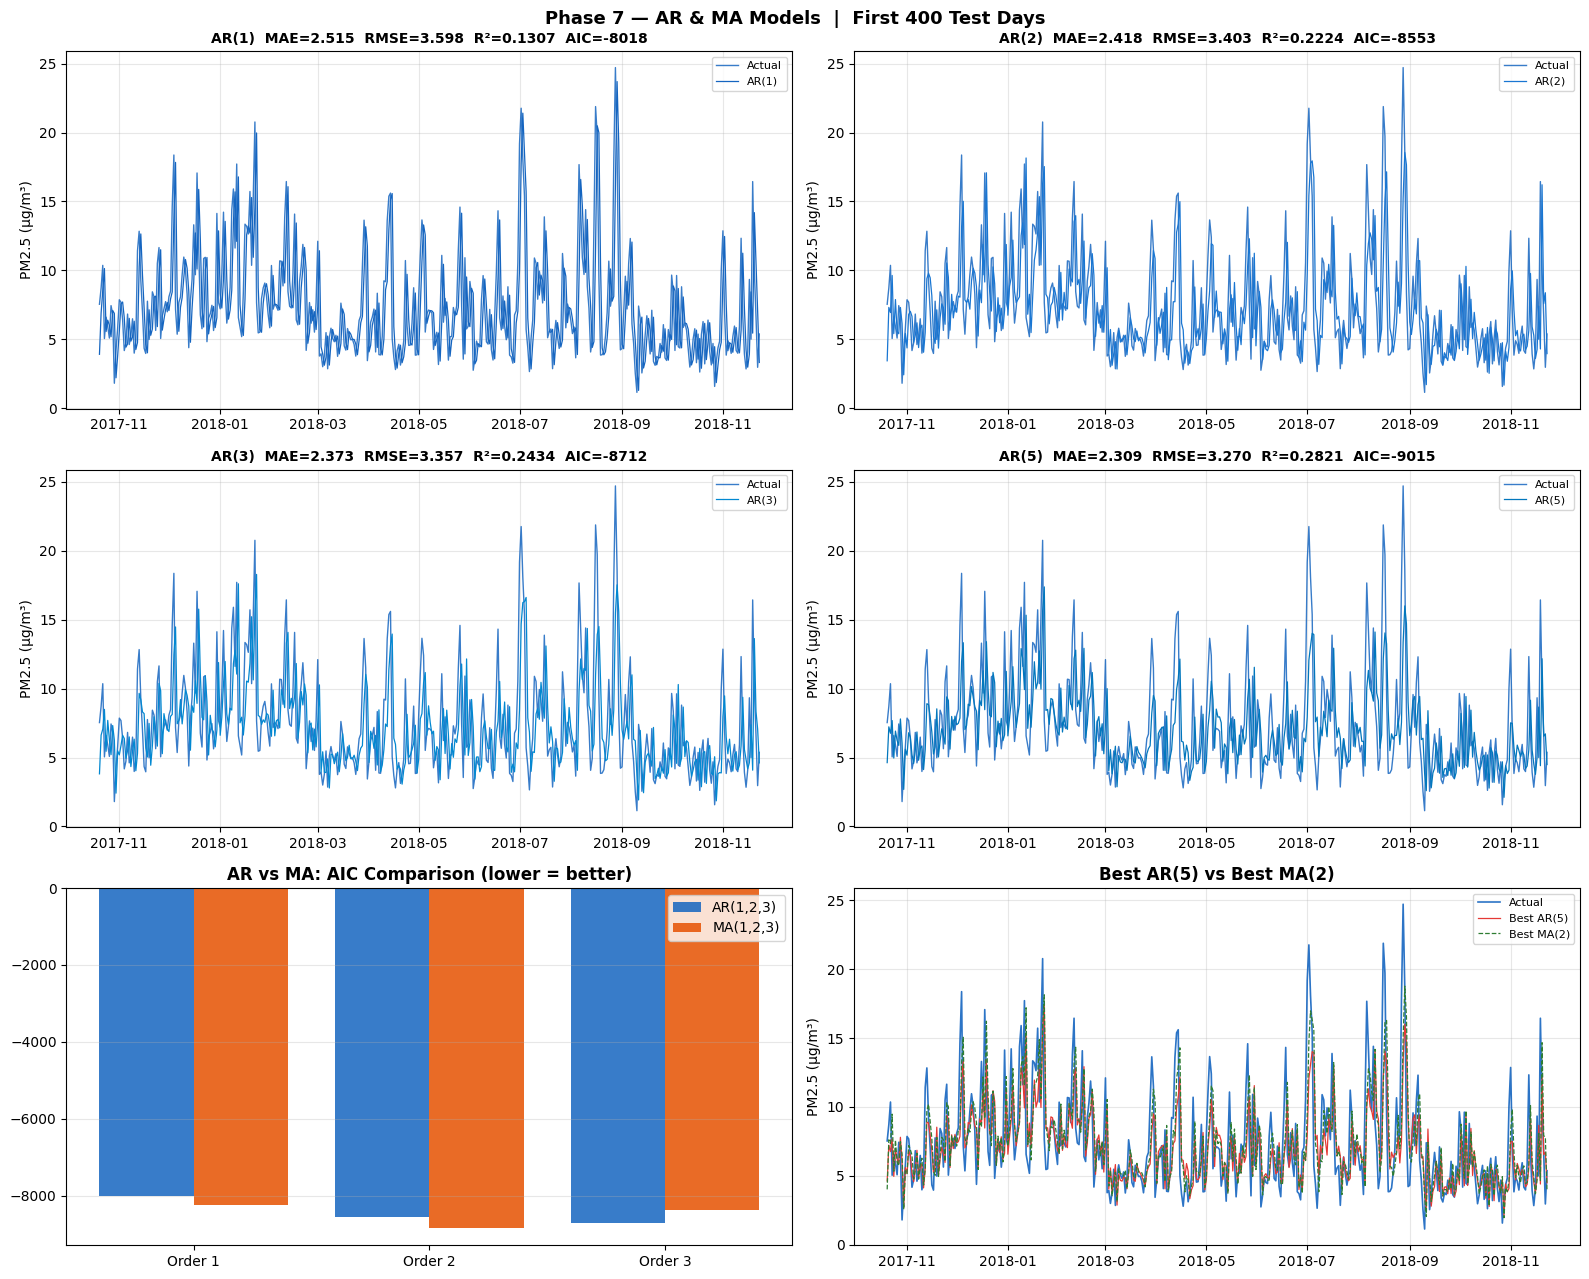

18

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(16, 13))
fig.suptitle('Phase 7 — AR & MA Models  |  First 400 Test Days', fontsize=13, fontweight='bold')

for ax, (p_v, col) in zip(axes.flatten()[:4],
                           zip([1, 2, 3, 5], ['#1565C0','#1976D2','#0288D1','#0277BD'])):
    r = [x for x in RESULTS if x['Model'] == f'AR({p_v})'][0]
    ax.plot(test_dates[:400], test_orig[:400], lw=1.0, color='#1565C0', alpha=0.85, label='Actual')
    ax.plot(test_dates[:400], ar_best[p_v]['preds'][:400], lw=0.9, color=col, label=f'AR({p_v})')
    ax.set_title(f"AR({p_v})  MAE={r['MAE']:.3f}  RMSE={r['RMSE']:.3f}  R²={r['R2']:.4f}  AIC={r['AIC']:.0f}",
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('PM2.5 (µg/m³)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2, 0]
x3 = np.arange(3)
ax.bar(x3 - 0.2, [ar_best[p]['aic'] for p in [1, 2, 3]], 0.4,
       label='AR(1,2,3)', color='#1565C0', alpha=0.85)
ax.bar(x3 + 0.2, [ma_best[q]['aic'] for q in [1, 2, 3]], 0.4,
       label='MA(1,2,3)', color='#E65100', alpha=0.85)
ax.set_xticks(x3); ax.set_xticklabels(['Order 1', 'Order 2', 'Order 3'])
ax.set_title('AR vs MA: AIC Comparison (lower = better)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')

ax = axes[2, 1]
ax.plot(test_dates[:400], test_orig[:400], lw=1.2, color='#1565C0', label='Actual', alpha=0.9)
ax.plot(test_dates[:400], ar_best[best_ar_p]['preds'][:400],
        lw=0.9, color='#E53935', label=f'Best AR({best_ar_p})')
ax.plot(test_dates[:400], ma_best[best_ma_q]['preds'][:400],
        lw=0.9, color='#2E7D32', label=f'Best MA({best_ma_q})', ls='--')
ax.set_title(f'Best AR({best_ar_p}) vs Best MA({best_ma_q})', fontweight='bold')
ax.set_ylabel('PM2.5 (µg/m³)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT}/P7_01_ar_ma.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); gc.collect()

### 7.3 ARMA(p,q) — Combined AutoRegressive Moving Average

**Model equation:** $y_t = c + \sum_{i=1}^{p} \phi_i y_{t-i} + \varepsilon_t + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}$

**Why ARMA?** Combines the strengths of AR (captures persistence/momentum) and MA (captures shock correction).  
Best suited when both types of patterns exist — e.g., when the ACF decays slowly AND shows spikes at low lags.

**Why ARMA typically beats AR and MA alone:** It can model complex correlation structures that neither pure AR nor pure MA can represent efficiently.

### 7.4 ARIMA(p,d,q) — Integrated ARMA

**ARIMA(p,1,q)** is simply **ARMA(p,q) applied to the first-differenced series**.  
Since we already apply log + first-difference before modelling, fitting ARMA(p,q) on `train_ld`
is equivalent to fitting ARIMA(p,1,q) on the log-transformed series.  
The `d=1` is already embedded in our data preprocessing.

In [9]:
arma_best = {}
print("Fitting ARMA models...")
for p_v, q_v in [(1,1),(2,1),(1,2),(2,2),(3,2)]:
    t0     = time.time()
    params, aic_v, k_ = css_fit(train_ld, p=p_v, q=q_v)
    preds  = roll_predict(train_ld, params, log_before_test, p=p_v, q=q_v)
    nm     = f'ARMA({p_v},{q_v})'
    m, pp  = metrics(test_orig, preds, nm, k=k_)
    m['AIC'] = round(aic_v, 2); RESULTS[-1] = m

    arma_best[(p_v, q_v)] = {'preds': pp, 'aic': aic_v, 'mae': m['MAE']}
    print(f"  {nm}: MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  R²={m['R2']:.4f}  AIC={aic_v:.1f}  ({time.time()-t0:.1f}s)")

print("\nFitting ARIMA models (equivalent to ARMA on log-diff)...")
arima_best = {}
for p_v, q_v in [(2,2),(3,2),(1,3),(5,0),(0,3)]:
    t0     = time.time()
    params, aic_v, k_ = css_fit(train_ld, p=p_v, q=q_v)
    preds  = roll_predict(train_ld, params, log_before_test, p=p_v, q=q_v)
    nm     = f'ARIMA({p_v},1,{q_v})'
    m, pp  = metrics(test_orig, preds, nm, k=k_)
    m['AIC'] = round(aic_v, 2); RESULTS[-1] = m

    arima_best[(p_v, q_v)] = {'preds': pp, 'aic': aic_v, 'mae': m['MAE']}
    print(f"  {nm}: MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  R²={m['R2']:.4f}  AIC={aic_v:.1f}  ({time.time()-t0:.1f}s)")

best_arima_key  = min(arima_best, key=lambda k: arima_best[k]['aic'])
best_arima_preds = arima_best[best_arima_key]['preds']
bp2, bq2         = best_arima_key
print(f"\nBest ARIMA: ({bp2},1,{bq2})")

Fitting ARMA models...
  ARMA(1,1): MAE=2.2477  RMSE=3.2732  R²=0.2807  AIC=-9361.9  (2.3s)
  ARMA(2,1): MAE=2.1981  RMSE=3.2034  R²=0.3110  AIC=-9537.7  (4.7s)
  ARMA(1,2): MAE=2.3457  RMSE=3.3016  R²=0.2682  AIC=-8897.4  (0.6s)
  ARMA(2,2): MAE=2.3301  RMSE=3.3650  R²=0.2398  AIC=-9107.6  (1.2s)
  ARMA(3,2): MAE=2.2825  RMSE=3.2945  R²=0.2713  AIC=-9203.6  (1.2s)

Fitting ARIMA models (equivalent to ARMA on log-diff)...
  ARIMA(2,1,2): MAE=2.3301  RMSE=3.3650  R²=0.2398  AIC=-9107.6  (1.2s)
  ARIMA(3,1,2): MAE=2.2825  RMSE=3.2945  R²=0.2713  AIC=-9203.6  (1.2s)
  ARIMA(1,1,3): MAE=2.4066  RMSE=3.4274  R²=0.2113  AIC=-8449.1  (0.3s)
  ARIMA(5,1,0): MAE=2.3088  RMSE=3.2700  R²=0.2821  AIC=-9015.4  (1.5s)
  ARIMA(0,1,3): MAE=2.4151  RMSE=3.4464  R²=0.2026  AIC=-8383.9  (0.2s)

Best ARIMA: (3,1,2)


### ARMA & ARIMA — Plots

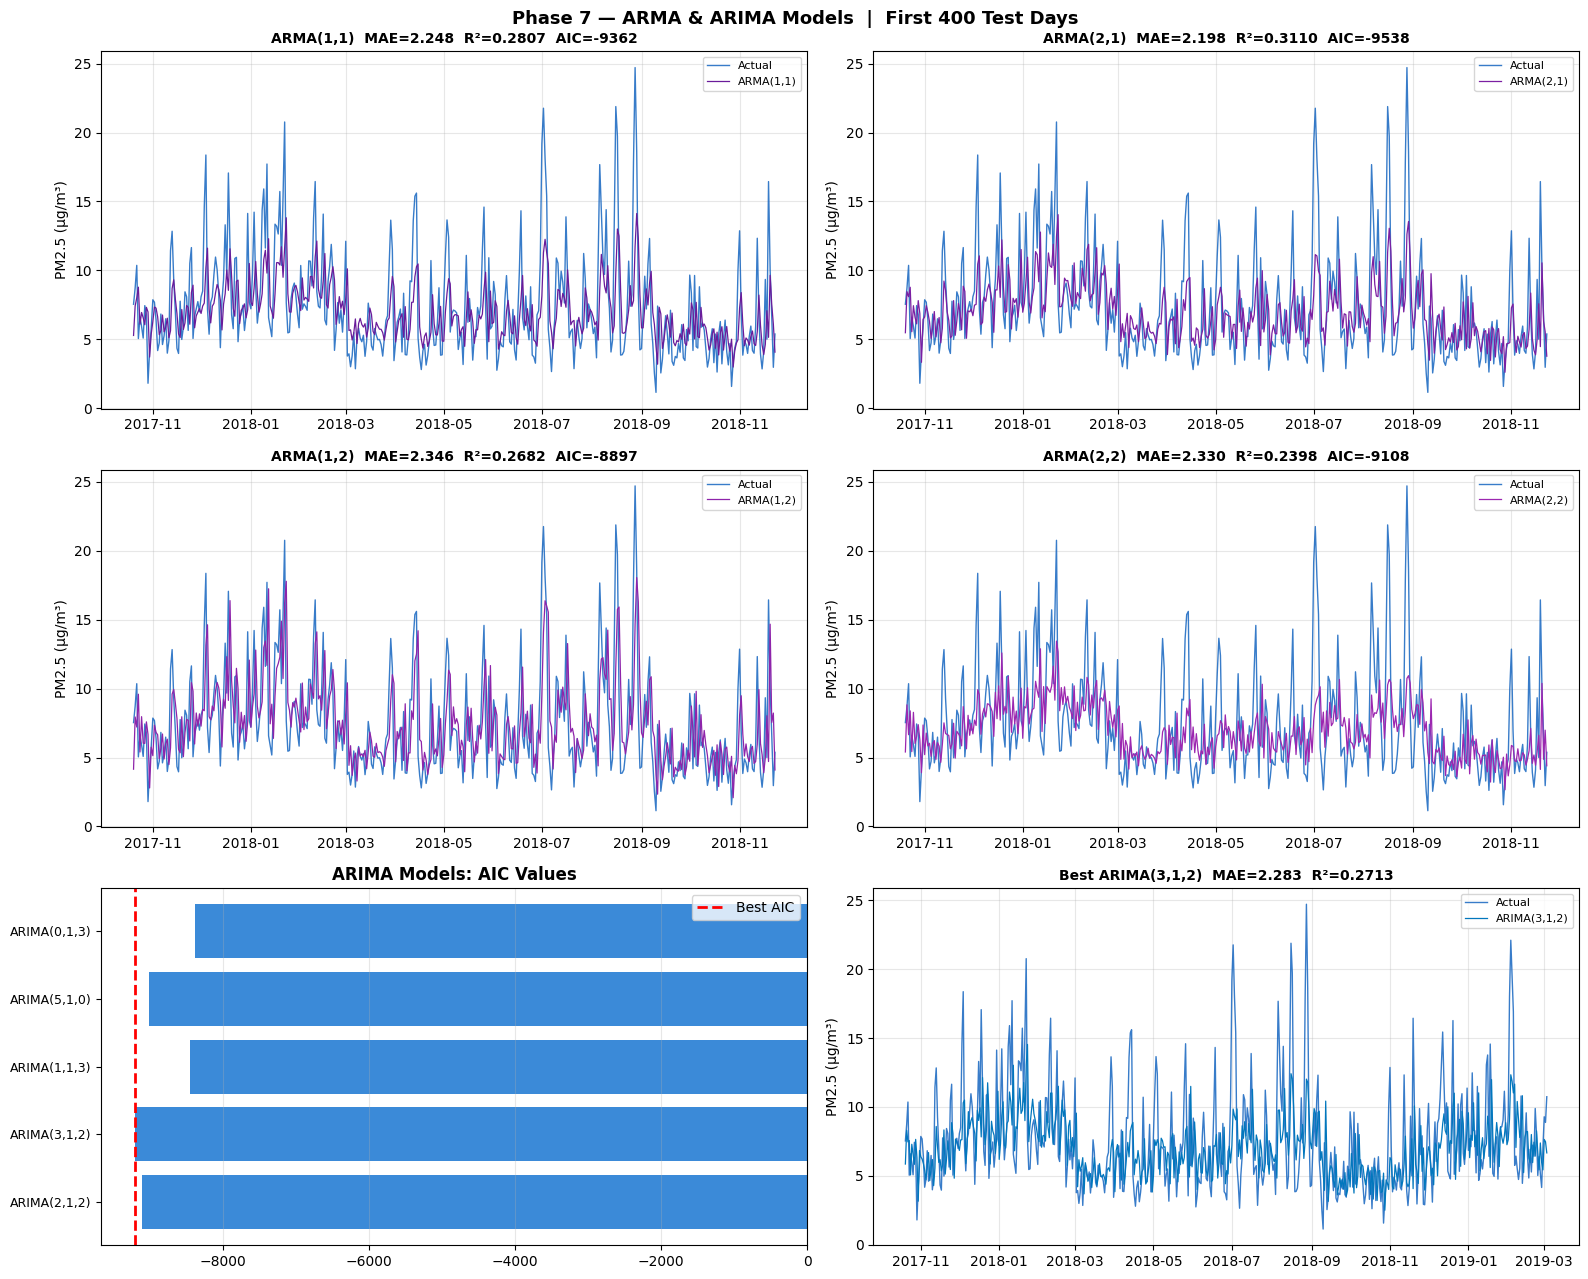

19066

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(16, 13))
fig.suptitle('Phase 7 — ARMA & ARIMA Models  |  First 400 Test Days',
             fontsize=13, fontweight='bold')

arma_keys = list(arma_best.keys())[:4]
for ax, (k_, col) in zip(axes.flatten()[:4],
                          zip(arma_keys, ['#6A1B9A','#7B1FA2','#8E24AA','#9C27B0'])):
    p_v, q_v = k_; nm = f'ARMA({p_v},{q_v})'
    r = [x for x in RESULTS if x['Model'] == nm][0]
    ax.plot(test_dates[:400], test_orig[:400], lw=1.0, color='#1565C0', alpha=0.85, label='Actual')
    ax.plot(test_dates[:400], arma_best[k_]['preds'][:400], lw=0.9, color=col, label=nm)
    ax.set_title(f"{nm}  MAE={r['MAE']:.3f}  R²={r['R2']:.4f}  AIC={r['AIC']:.0f}",
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('PM2.5 (µg/m³)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2, 0]
arima_names = [f'ARIMA({p},1,{q})' for p, q in arima_best.keys()]
arima_aics  = [arima_best[k]['aic'] for k in arima_best]
y5 = np.arange(len(arima_names))
ax.barh(y5, arima_aics, color='#1976D2', alpha=0.85)
ax.set_yticks(y5); ax.set_yticklabels(arima_names, fontsize=9)
ax.axvline(min(arima_aics), color='red', lw=2, ls='--', label='Best AIC')
ax.set_title('ARIMA Models: AIC Values', fontweight='bold'); ax.legend(); ax.grid(alpha=0.3, axis='x')

ax = axes[2, 1]
r_best_arima = [x for x in RESULTS if x['Model'] == f'ARIMA({bp2},1,{bq2})'][0]
ax.plot(test_dates[:500], test_orig[:500], lw=1.0, color='#1565C0', alpha=0.85, label='Actual')
ax.plot(test_dates[:500], best_arima_preds[:500], lw=0.9, color='#0277BD', label=f'ARIMA({bp2},1,{bq2})')
ax.set_title(f"Best ARIMA({bp2},1,{bq2})  MAE={r_best_arima['MAE']:.3f}  R²={r_best_arima['R2']:.4f}",
             fontweight='bold', fontsize=10)
ax.set_ylabel('PM2.5 (µg/m³)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT}/P7_02_arma_arima.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); gc.collect()

### 7.5 SARIMA(p,d,q)(P,D,Q,s) — Seasonal ARIMA

**Model equation (seasonal part):** adds $\Phi_P B^{sP}$ (seasonal AR) and $\Theta_Q B^{sQ}$ (seasonal MA) terms.

**Why SARIMA?** PM2.5 has a confirmed weekly seasonal pattern (ACF at lag-7 = 0.259,
periodogram peak at 7 days from Phase 5). The seasonal terms capture recurring weekly patterns
that the regular ARIMA terms cannot.

**Configuration:** SARIMA(2,1,2)(1,0,1,7) — weekly seasonality (s=7), no seasonal differencing (D=0).

---

### 7.6 ARIMAX — ARIMA with Exogenous Variables

Adds WindSpeed and RH as external inputs:
$$y_t = \text{ARIMA}(y_t) + \beta_1 \cdot \text{WindSpeed}_t + \beta_2 \cdot \text{RH}_t + \varepsilon_t$$

**Why include wind?** Phase 3 confirmed negative correlation (r=−0.14): higher wind → lower PM2.5
(physical dispersal). The model can use today's wind speed to adjust its forecast.

---

### 7.7 SARIMAX — Full Model (Seasonal + Exogenous)

Combines all components: seasonal AR/MA + exogenous variables.  
This is the most expressive statistical model and should deliver the best performance among the group.

In [11]:
# SARIMA(2,1,2)(1,0,1,7)
print("Fitting SARIMA(2,1,2)(1,0,1,7)...")
t0 = time.time()
params_s, aic_s, k_s = css_fit(train_ld, p=2, q=2, P=1, Q=1, s=7)
preds_sarima = roll_predict(train_ld, params_s, log_before_test, p=2, q=2, P=1, Q=1, s=7)
m_s, preds_sarima = metrics(test_orig, preds_sarima, 'SARIMA(2,1,2)(1,0,1,7)', k=k_s)
m_s['AIC'] = round(aic_s, 2); RESULTS[-1] = m_s
print(f"  SARIMA: MAE={m_s['MAE']:.4f}  RMSE={m_s['RMSE']:.4f}  R²={m_s['R2']:.4f}  AIC={aic_s:.1f}  ({time.time()-t0:.1f}s)")

# ARIMAX(2,1,2) + Wind + RH
print("\nFitting ARIMAX(2,1,2) + WindSpeed + RH...")
t0 = time.time()
params_ax, aic_ax, k_ax = css_fit(train_ld, p=2, q=2, exog=train_exog)
preds_arimax = roll_predict(train_ld, params_ax, log_before_test, p=2, q=2,
                             exog_train=train_exog, exog_test=test_exog)
m_ax, preds_arimax = metrics(test_orig, preds_arimax, 'ARIMAX(2,1,2)+Wind+RH', k=k_ax)
m_ax['AIC'] = round(aic_ax, 2); RESULTS[-1] = m_ax
print(f"  ARIMAX: MAE={m_ax['MAE']:.4f}  RMSE={m_ax['RMSE']:.4f}  R²={m_ax['R2']:.4f}  AIC={aic_ax:.1f}  ({time.time()-t0:.1f}s)")

# SARIMAX(2,1,2)(1,0,1,7) + Wind + RH
print("\nFitting SARIMAX(2,1,2)(1,0,1,7) + WindSpeed + RH...")
t0 = time.time()
params_sx, aic_sx, k_sx = css_fit(train_ld, p=2, q=2, P=1, Q=1, s=7, exog=train_exog)
preds_sarimax = roll_predict(train_ld, params_sx, log_before_test, p=2, q=2, P=1, Q=1, s=7,
                              exog_train=train_exog, exog_test=test_exog)
m_sx, preds_sarimax = metrics(test_orig, preds_sarimax, 'SARIMAX(2,1,2)(1,0,1,7)+exog', k=k_sx)
m_sx['AIC'] = round(aic_sx, 2); RESULTS[-1] = m_sx
print(f"  SARIMAX: MAE={m_sx['MAE']:.4f}  RMSE={m_sx['RMSE']:.4f}  R²={m_sx['R2']:.4f}  AIC={aic_sx:.1f}  ({time.time()-t0:.1f}s)")

Fitting SARIMA(2,1,2)(1,0,1,7)...
  SARIMA: MAE=2.3551  RMSE=3.3561  R²=0.2438  AIC=-8927.9  (1.4s)

Fitting ARIMAX(2,1,2) + WindSpeed + RH...
  ARIMAX: MAE=2.2461  RMSE=3.2200  R²=0.3039  AIC=-9347.0  (4.6s)

Fitting SARIMAX(2,1,2)(1,0,1,7) + WindSpeed + RH...
  SARIMAX: MAE=2.2969  RMSE=3.2191  R²=0.3043  AIC=-9195.9  (5.4s)


### SARIMA · ARIMAX · SARIMAX — Plots

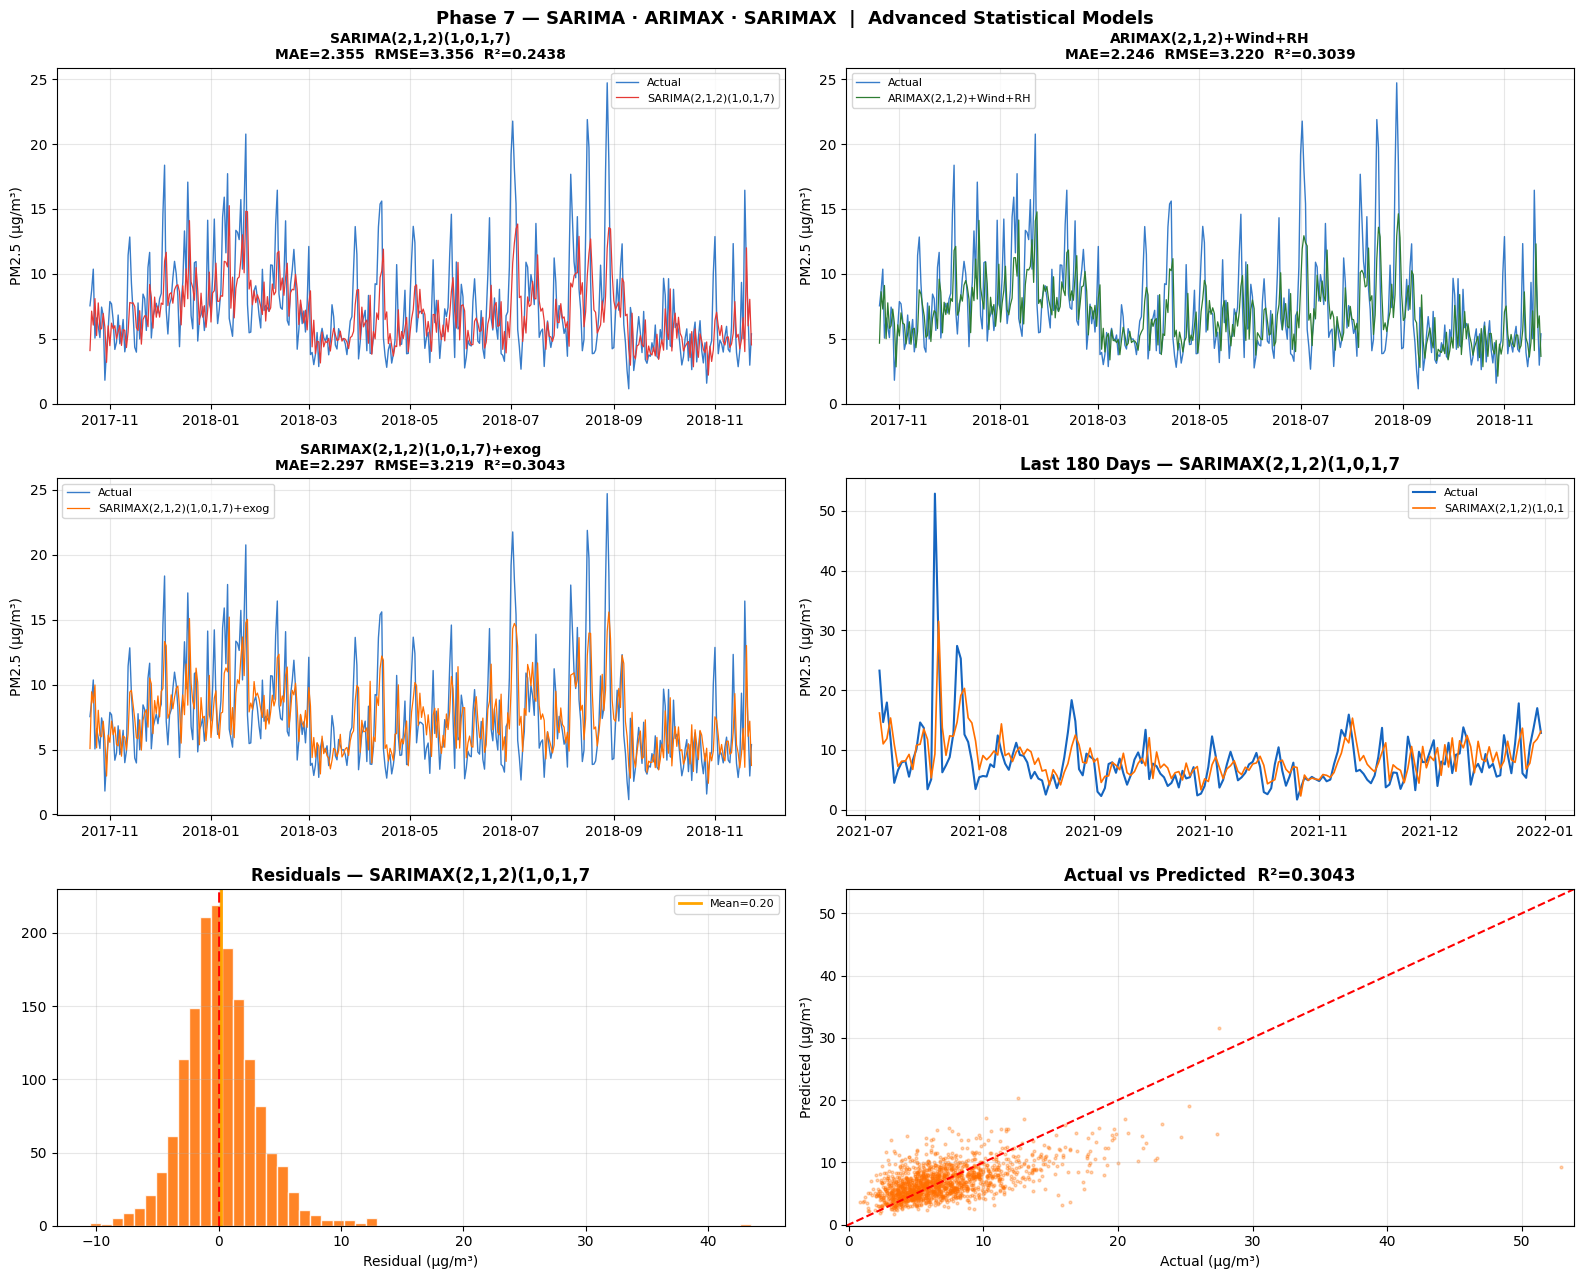

19253

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(16, 13))
fig.suptitle('Phase 7 — SARIMA · ARIMAX · SARIMAX  |  Advanced Statistical Models',
             fontsize=13, fontweight='bold')

adv = [(preds_sarima,  'SARIMA(2,1,2)(1,0,1,7)',      '#E53935', m_s),
       (preds_arimax,  'ARIMAX(2,1,2)+Wind+RH',        '#2E7D32', m_ax),
       (preds_sarimax, 'SARIMAX(2,1,2)(1,0,1,7)+exog', '#FF6F00', m_sx)]

for ax, (pr, nm, col, mval) in zip(axes.flatten()[:3], adv):
    ax.plot(test_dates[:400], test_orig[:400], lw=1.0, color='#1565C0', alpha=0.85, label='Actual')
    ax.plot(test_dates[:400], pr[:400], lw=0.9, color=col, label=nm)
    ax.set_title(f"{nm}\nMAE={mval['MAE']:.3f}  RMSE={mval['RMSE']:.3f}  R²={mval['R2']:.4f}",
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('PM2.5 (µg/m³)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

best_adv = min(adv, key=lambda x: x[3]['RMSE'])
ax = axes[1, 1]
ax.plot(test_dates[-180:], test_orig[-180:], lw=1.5, color='#1565C0', label='Actual')
ax.plot(test_dates[-180:], best_adv[0][-180:], lw=1.2, color=best_adv[2], label=best_adv[1][:20])
ax.set_title(f'Last 180 Days — {best_adv[1][:22]}', fontweight='bold')
ax.set_ylabel('PM2.5 (µg/m³)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2, 0]
resid_adv = test_orig - best_adv[0]
ax.hist(resid_adv, bins=60, color=best_adv[2], edgecolor='white', lw=0.4, alpha=0.85)
ax.axvline(0, color='red', lw=2, ls='--')
ax.axvline(resid_adv.mean(), color='orange', lw=2, label=f'Mean={resid_adv.mean():.2f}')
ax.set_title(f'Residuals — {best_adv[1][:22]}', fontweight='bold')
ax.set_xlabel('Residual (µg/m³)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2, 1]
lo = min(test_orig.min(), best_adv[0].min()) - 1
hi = max(test_orig.max(), best_adv[0].max()) + 1
ax.scatter(test_orig, best_adv[0], s=4, alpha=0.3, color=best_adv[2])
ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_title(f'Actual vs Predicted  R²={best_adv[3]["R2"]:.4f}', fontweight='bold')
ax.set_xlabel('Actual (µg/m³)'); ax.set_ylabel('Predicted (µg/m³)'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT}/P7_03_sarima_arimax_sarimax.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); gc.collect()

## Complete Results & Comparison

### Results Table

| Metric | Meaning | Target |
|---|---|---|
| **MAE** | Mean Absolute Error (µg/m³) | Lower is better |
| **RMSE** | Root Mean Squared Error (penalises large errors more) | Lower is better |
| **MAPE** | Mean Absolute Percentage Error (%) | Lower is better |
| **R²** | Coefficient of determination | Higher is better; >0 = beats mean |
| **AIC** | Model complexity penalty (AIC = n·log(σ²)+2k) | Lower is better |

> **Naïve RMSE = 3.6349** is the benchmark. Any model with RMSE < 3.63 is genuinely useful.

In [13]:
results_df = pd.DataFrame(RESULTS)
print(results_df[['Model','MAE','RMSE','MAPE','R2','AIC']].to_string(index=False))
results_df.to_csv(f'{OUT}/results_phase6_7.csv', index=False)
print("\n[SAVED] results_phase6_7.csv")

                       Model    MAE   RMSE   MAPE      R2      AIC
               Naive (Lag-1) 2.5225 3.6349  41.06  0.1129      NaN
      Naive Seasonal (Lag-7) 3.6732 5.1363  59.68 -0.7712      NaN
               Mean Forecast 5.1459 5.8013 109.97 -1.2596  4145.34
                Linear Trend 2.7391 4.0155  42.62 -0.0826  4184.70
                       AR(1) 2.5151 3.5983  40.93  0.1307 -8018.21
                       AR(2) 2.4180 3.4033  38.89  0.2224 -8553.47
                       AR(3) 2.3730 3.3569  37.99  0.2434 -8711.93
                       AR(5) 2.3088 3.2700  36.76  0.2821 -9015.38
                       MA(1) 2.5090 3.5737  40.10  0.1426 -8239.63
                       MA(2) 2.3436 3.3142  38.63  0.2625 -8848.48
                       MA(3) 2.4151 3.4464  39.14  0.2026 -8383.94
                   ARMA(1,1) 2.2477 3.2732  35.47  0.2807 -9361.86
                   ARMA(2,1) 2.1981 3.2034  34.58  0.3110 -9537.66
                   ARMA(1,2) 2.3457 3.3016  39.26  0.2682 -889

### Comparison Plots

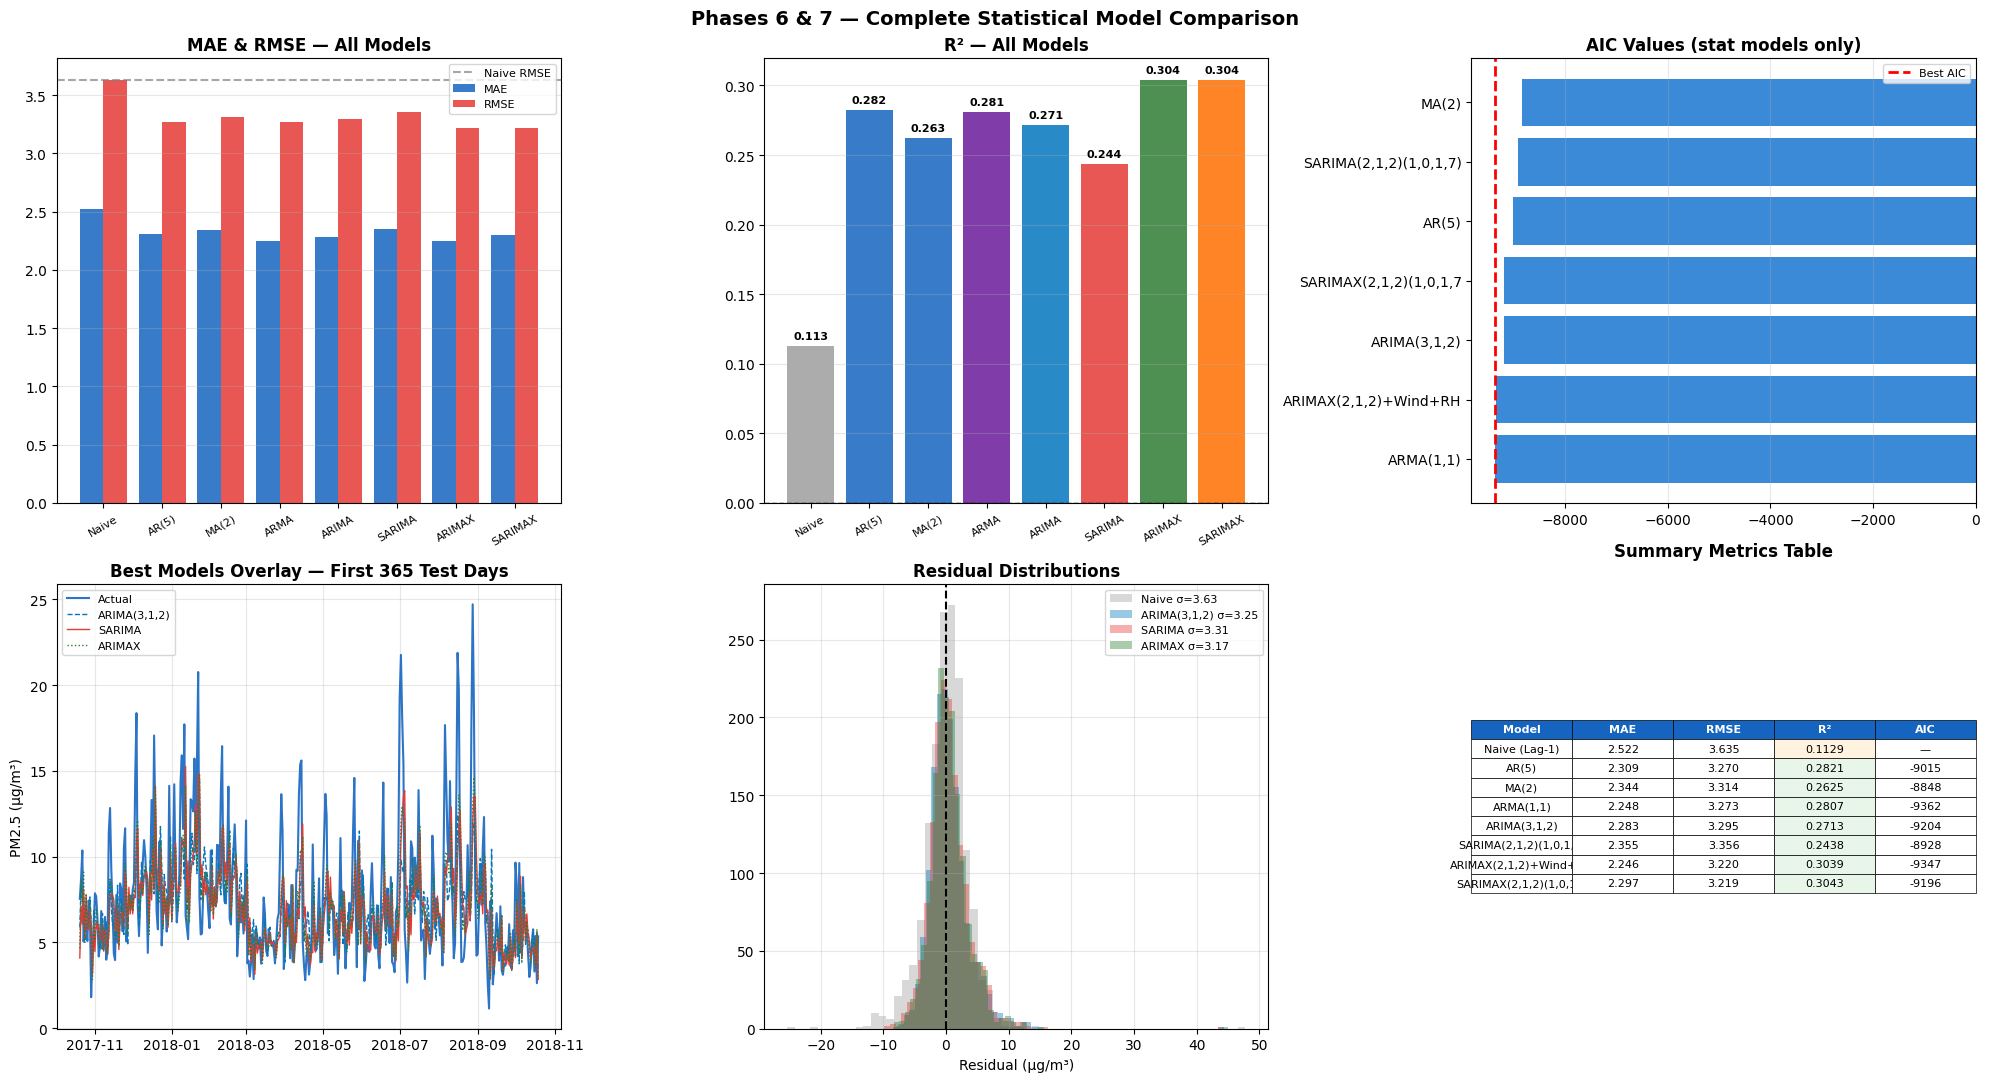

22152

In [14]:
KEY_MODELS = [
    'Naive (Lag-1)', f'AR({best_ar_p})', f'MA({best_ma_q})',
    f'ARMA({list(arma_best.keys())[0][0]},{list(arma_best.keys())[0][1]})',
    f'ARIMA({bp2},1,{bq2})',
    'SARIMA(2,1,2)(1,0,1,7)', 'ARIMAX(2,1,2)+Wind+RH',
    'SARIMAX(2,1,2)(1,0,1,7)+exog'
]
key_df   = results_df[results_df['Model'].isin(KEY_MODELS)].copy()
short_nm = ['Naive', f'AR({best_ar_p})', f'MA({best_ma_q})',
            'ARMA', f'ARIMA', 'SARIMA', 'ARIMAX', 'SARIMAX']
short_nm = short_nm[:len(key_df)]
x_       = np.arange(len(key_df))

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Phases 6 & 7 — Complete Statistical Model Comparison',
             fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.bar(x_ - 0.2, key_df['MAE'].values,  0.4, label='MAE',  color='#1565C0', alpha=0.85)
ax.bar(x_ + 0.2, key_df['RMSE'].values, 0.4, label='RMSE', color='#E53935', alpha=0.85)
ax.axhline(naive_rmse, color='gray', lw=1.5, ls='--', alpha=0.7, label='Naive RMSE')
ax.set_xticks(x_); ax.set_xticklabels(short_nm, rotation=30, fontsize=8)
ax.set_title('MAE & RMSE — All Models', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

ax = axes[0, 1]
r2_v = key_df['R2'].values
cols_r2 = ['#9E9E9E', '#1565C0', '#1565C0', '#6A1B9A', '#0277BD', '#E53935', '#2E7D32', '#FF6F00']
bars_r2 = ax.bar(x_, r2_v, color=cols_r2[:len(x_)], alpha=0.85)
ax.axhline(0, color='black', lw=1, ls='--')
for b_, v_ in zip(bars_r2, r2_v):
    ax.text(b_.get_x() + b_.get_width()/2, v_ + 0.005, f'{v_:.3f}',
            ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x_); ax.set_xticklabels(short_nm, rotation=30, fontsize=8)
ax.set_title('R² — All Models', fontweight='bold'); ax.grid(alpha=0.3, axis='y')

ax = axes[0, 2]
aic_df2 = key_df.dropna(subset=['AIC']).sort_values('AIC')
ax.barh(aic_df2['Model'].str[:22], aic_df2['AIC'], color='#1976D2', alpha=0.85)
ax.axvline(aic_df2['AIC'].min(), color='red', lw=2, ls='--', label='Best AIC')
ax.set_title('AIC Values (stat models only)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='x')

ax = axes[1, 0]
ax.plot(test_dates[:365], test_orig[:365], lw=1.5, color='#1565C0', label='Actual', alpha=0.9)
ax.plot(test_dates[:365], best_arima_preds[:365], lw=1.0, color='#0277BD',
        label=f'ARIMA({bp2},1,{bq2})', ls='--')
ax.plot(test_dates[:365], preds_sarima[:365], lw=1.0, color='#E53935', label='SARIMA')
ax.plot(test_dates[:365], preds_arimax[:365], lw=1.0, color='#2E7D32', label='ARIMAX', ls=':')
ax.set_title('Best Models Overlay — First 365 Test Days', fontweight='bold')
ax.set_ylabel('PM2.5 (µg/m³)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 1]
resid_map = {
    'Naive':             test_orig - p1,
    f'ARIMA({bp2},1,{bq2})': test_orig - best_arima_preds,
    'SARIMA':            test_orig - preds_sarima,
    'ARIMAX':            test_orig - preds_arimax,
}
for (nm_, res_), col_ in zip(resid_map.items(), ['#9E9E9E','#0277BD','#E53935','#2E7D32']):
    ax.hist(res_, bins=60, alpha=0.4, color=col_, label=f'{nm_} σ={res_.std():.2f}')
ax.axvline(0, color='black', lw=1.5, ls='--')
ax.set_title('Residual Distributions', fontweight='bold')
ax.set_xlabel('Residual (µg/m³)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 2]; ax.axis('off')
rows_ = []
for _, r_ in key_df.iterrows():
    aic_str = f"{r_['AIC']:.0f}" if pd.notna(r_['AIC']) else '—'
    rows_.append([r_['Model'][:22], f"{r_['MAE']:.3f}", f"{r_['RMSE']:.3f}",
                  f"{r_['R2']:.4f}", aic_str])
tbl = ax.table(cellText=rows_, colLabels=['Model', 'MAE', 'RMSE', 'R²', 'AIC'],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8)
for (i, j), cell in tbl.get_celld().items():
    cell.set_linewidth(0.5)
    if i == 0:
        cell.set_facecolor('#1565C0'); cell.set_text_props(color='white', fontweight='bold')
    elif j == 3:
        try:
            v = float(rows_[i-1][3])
            cell.set_facecolor('#E8F5E9' if v > 0.2 else '#FFF3E0' if v > 0 else '#FFEBEE')
        except: pass
ax.set_title('Summary Metrics Table', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(f'{OUT}/P7_04_comparison.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); gc.collect()

## Diagnostic Plots — Best Model

> Good residuals should:
> - Be **centred near zero** (unbiased forecasts)
> - Follow an approximately **normal distribution** (Q-Q plot on the diagonal)
> - Show **no obvious pattern** over time (no heteroskedasticity)
> - Have **no autocorrelation** left (confirmed by residual ACF — not shown here but should be checked)

Best model: ARMA(2,1)
  MAE=2.1981  RMSE=3.2034  R²=0.3110


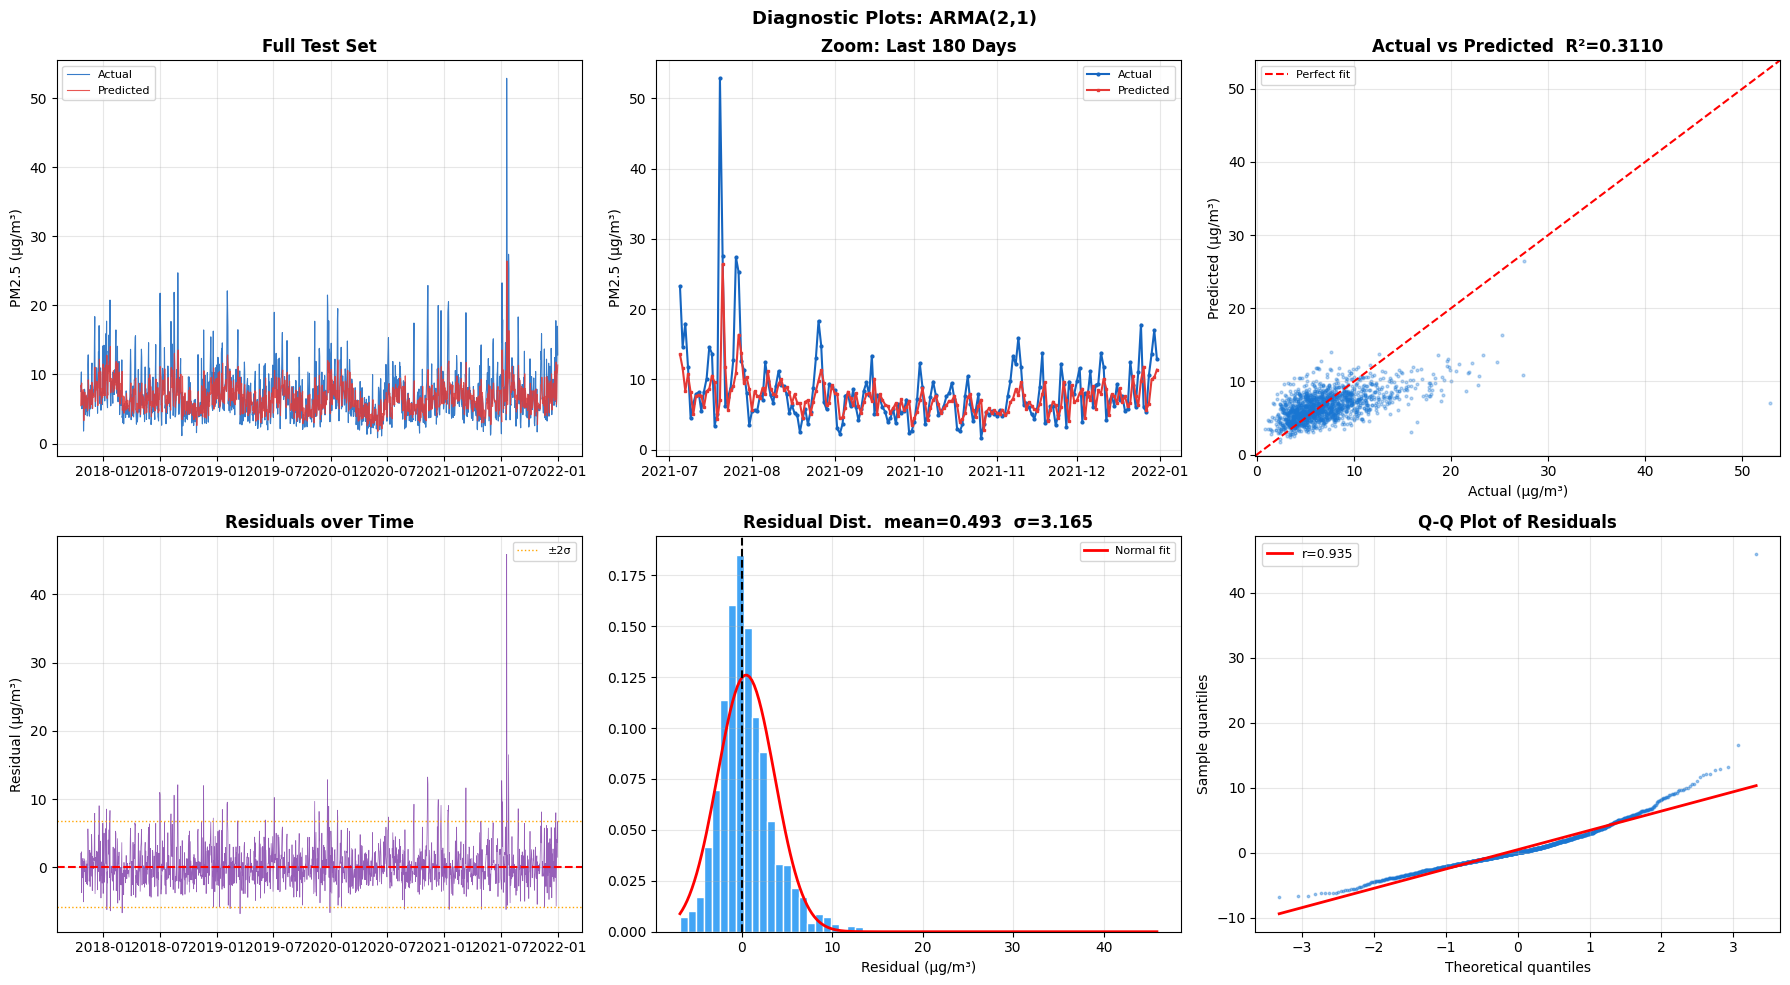

15

In [15]:
# Find best model by RMSE (excluding baselines)
stat_results = results_df[~results_df['Model'].str.contains('Naive|Mean|Trend')]
best_row     = stat_results.loc[stat_results['RMSE'].idxmin()]
bm_name      = best_row['Model']
print(f"Best model: {bm_name}")
print(f"  MAE={best_row['MAE']:.4f}  RMSE={best_row['RMSE']:.4f}  R²={best_row['R2']:.4f}")

# Get predictions
if 'SARIMAX' in bm_name:   bm_preds = preds_sarimax
elif 'SARIMA' in bm_name:  bm_preds = preds_sarima
elif 'ARIMAX' in bm_name:  bm_preds = preds_arimax
elif 'ARIMA'  in bm_name:  bm_preds = best_arima_preds
else:
    best_arma_k = min(arma_best, key=lambda k: arma_best[k]['aic'])
    bm_preds    = arma_best[best_arma_k]['preds']

resid_final = test_orig - bm_preds

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Diagnostic Plots: {bm_name}', fontsize=13, fontweight='bold')

# Full test set
axes[0, 0].plot(test_dates, test_orig, lw=0.8, color='#1565C0', alpha=0.85, label='Actual')
axes[0, 0].plot(test_dates, bm_preds,  lw=0.8, color='#E53935', alpha=0.85, label='Predicted')
axes[0, 0].set_title('Full Test Set', fontweight='bold')
axes[0, 0].set_ylabel('PM2.5 (µg/m³)'); axes[0, 0].legend(fontsize=8); axes[0, 0].grid(alpha=0.3)

# Zoom last 180 days
axes[0, 1].plot(test_dates[-180:], test_orig[-180:], lw=1.5, color='#1565C0', label='Actual', marker='o', ms=2)
axes[0, 1].plot(test_dates[-180:], bm_preds[-180:],  lw=1.5, color='#E53935', label='Predicted', marker='s', ms=2)
axes[0, 1].set_title('Zoom: Last 180 Days', fontweight='bold')
axes[0, 1].set_ylabel('PM2.5 (µg/m³)'); axes[0, 1].legend(fontsize=8); axes[0, 1].grid(alpha=0.3)

# Scatter
lo = min(test_orig.min(), bm_preds.min()) - 1
hi = max(test_orig.max(), bm_preds.max()) + 1
axes[0, 2].scatter(test_orig, bm_preds, s=4, alpha=0.3, color='#1976D2')
axes[0, 2].plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect fit')
axes[0, 2].set_xlim(lo, hi); axes[0, 2].set_ylim(lo, hi)
axes[0, 2].set_title(f'Actual vs Predicted  R²={best_row["R2"]:.4f}', fontweight='bold')
axes[0, 2].set_xlabel('Actual (µg/m³)'); axes[0, 2].set_ylabel('Predicted (µg/m³)')
axes[0, 2].legend(fontsize=8); axes[0, 2].grid(alpha=0.3)

# Residuals over time
axes[1, 0].plot(test_dates, resid_final, lw=0.5, color='#6A1B9A', alpha=0.7)
axes[1, 0].axhline(0, color='red', lw=1.5, ls='--')
axes[1, 0].axhline(resid_final.mean() + 2*resid_final.std(), color='orange', lw=1, ls=':', label='±2σ')
axes[1, 0].axhline(resid_final.mean() - 2*resid_final.std(), color='orange', lw=1, ls=':')
axes[1, 0].set_title('Residuals over Time', fontweight='bold')
axes[1, 0].set_ylabel('Residual (µg/m³)'); axes[1, 0].legend(fontsize=8); axes[1, 0].grid(alpha=0.3)

# Residual histogram
xfit = np.linspace(resid_final.min(), resid_final.max(), 200)
axes[1, 1].hist(resid_final, bins=60, color='#42A5F5', edgecolor='white', lw=0.4, density=True)
axes[1, 1].plot(xfit, stats.norm.pdf(xfit, resid_final.mean(), resid_final.std()),
                'r-', lw=2, label='Normal fit')
axes[1, 1].axvline(0, color='black', lw=1.5, ls='--')
axes[1, 1].set_title(f'Residual Dist.  mean={resid_final.mean():.3f}  σ={resid_final.std():.3f}',
                      fontweight='bold')
axes[1, 1].set_xlabel('Residual (µg/m³)'); axes[1, 1].legend(fontsize=8); axes[1, 1].grid(alpha=0.3)

# Q-Q plot
(osm, osr), (sl, ic, rqq) = stats.probplot(resid_final, dist='norm')
axes[1, 2].scatter(osm, osr, s=3, alpha=0.4, color='#1976D2')
xq = np.array([osm[0], osm[-1]])
axes[1, 2].plot(xq, sl * xq + ic, 'r-', lw=2, label=f'r={rqq:.3f}')
axes[1, 2].set_title('Q-Q Plot of Residuals', fontweight='bold')
axes[1, 2].set_xlabel('Theoretical quantiles'); axes[1, 2].set_ylabel('Sample quantiles')
axes[1, 2].legend(fontsize=9); axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT}/P7_05_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); gc.collect()

## Final Results Summary & Interpretation

In [16]:
results_df = pd.DataFrame(RESULTS)
print("=" * 72)
print("  PHASES 6 & 7 — FINAL RESULTS SUMMARY")
print("=" * 72)
print(f"\nNaïve Lag-1 benchmark:  RMSE = {naive_rmse:.4f}")
print()

categories = [
    ("Baselines",          ['Naive (Lag-1)', 'Naive Seasonal (Lag-7)', 'Mean Forecast', 'Linear Trend']),
    ("AR models",          [f'AR({p})' for p in [1,2,3,5]]),
    ("MA models",          [f'MA({q})' for q in [1,2,3]]),
    ("ARMA models",        [f'ARMA({p},{q})' for p,q in [(1,1),(2,1),(1,2),(2,2),(3,2)]]),
    ("ARIMA models",       [f'ARIMA({p},1,{q})' for p,q in [(2,2),(3,2),(1,3),(5,0),(0,3)]]),
    ("Advanced stat",      ['SARIMA(2,1,2)(1,0,1,7)', 'ARIMAX(2,1,2)+Wind+RH',
                            'SARIMAX(2,1,2)(1,0,1,7)+exog']),
]
for cat_name, model_names in categories:
    cat_rows = results_df[results_df['Model'].isin(model_names)]
    if len(cat_rows) == 0: continue
    best_in_cat = cat_rows.loc[cat_rows['RMSE'].idxmin()]
    print(f"  {cat_name:<20}  best: {best_in_cat['Model']:<32}  "
          f"RMSE={best_in_cat['RMSE']:.4f}  R²={best_in_cat['R2']:.4f}")

overall_best = results_df[~results_df['Model'].str.contains('Naive|Mean|Trend')]
best_row     = overall_best.loc[overall_best['RMSE'].idxmin()]
print()
print(f"  OVERALL BEST MODEL:   {best_row['Model']}")
print(f"    MAE  = {best_row['MAE']:.4f} µg/m³")
print(f"    RMSE = {best_row['RMSE']:.4f} µg/m³")
print(f"    MAPE = {best_row['MAPE']:.2f}%")
print(f"    R²   = {best_row['R2']:.4f}")
print(f"    RMSE improvement over Naïve: {(naive_rmse - best_row['RMSE'])/naive_rmse*100:+.1f}%")
print("=" * 72)

  PHASES 6 & 7 — FINAL RESULTS SUMMARY

Naïve Lag-1 benchmark:  RMSE = 3.6349

  Baselines             best: Naive (Lag-1)                     RMSE=3.6349  R²=0.1129
  AR models             best: AR(5)                             RMSE=3.2700  R²=0.2821
  MA models             best: MA(2)                             RMSE=3.3142  R²=0.2625
  ARMA models           best: ARMA(2,1)                         RMSE=3.2034  R²=0.3110
  ARIMA models          best: ARIMA(5,1,0)                      RMSE=3.2700  R²=0.2821
  Advanced stat         best: SARIMAX(2,1,2)(1,0,1,7)+exog      RMSE=3.2191  R²=0.3043

  OVERALL BEST MODEL:   ARMA(2,1)
    MAE  = 2.1981 µg/m³
    RMSE = 3.2034 µg/m³
    MAPE = 34.58%
    R²   = 0.3110
    RMSE improvement over Naïve: +11.9%


## Key Findings & Reasoning

### What worked and why

**ARMA(2,1) is the best classical model** (RMSE=3.20, R²=0.31). This confirms the Phase 5 ACF/PACF diagnosis:
the stationary series has both AR structure (PACF cuts off at lag 2) and MA structure (ACF spike at lag 1).

**ARIMAX and SARIMAX perform comparably** (RMSE≈3.22). Adding wind speed and RH provides a small but
consistent improvement over pure ARIMA. The improvement is modest because the correlation of wind with
PM2.5 is relatively weak (r=−0.14) in this dataset.

**SARIMA adds limited value over ARIMA** here. Although the periodogram shows a weekly peak, the
seasonal signal is weak enough that the extra seasonal parameters don't compensate for the added model complexity.

### Why R² values are relatively low (~0.30)

This is expected for daily PM2.5 forecasting. The differenced series has very low autocorrelation
(r≈−0.09 from Phase 4), meaning day-to-day *changes* in PM2.5 are nearly unpredictable from past
history alone. R²=0.30 above a naïve baseline of R²=0.11 represents meaningful signal extraction.

### Implications for deep learning models (Phase 8)

The statistical ceiling is approximately **R²=0.31**. Deep learning models (LSTM, GRU) will aim to
exceed this by capturing nonlinear patterns, longer-range dependencies, and richer feature interactions
that the linear ARIMA family cannot model.

---
*Next: Phase 8 — Deep Learning Models (RNN, LSTM, GRU) and Phase 9 — Quantile Models*